In [1]:
# Important libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam, SGD

#from keras.models import Sequential
#from keras.layers import Dense

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score

iris = load_iris()
X = iris['data']
y = iris['target']
names = iris['target_names']
feature_names = iris['feature_names']

In [4]:
print('X.shape = ',X.shape,' ;  y.shape = ',y.shape)
print('')
print('First five rows of the four input features = ')
print(X[0:5,0:4])
print('')
print('First five desired outputs:')
print(y[0:5])
print('names: ',names)
print('feature_names: ',feature_names)

X.shape =  (150, 4)  ;  y.shape =  (150,)

First five rows of the four input features = 
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]

First five desired outputs:
[0 0 0 0 0]
names:  ['setosa' 'versicolor' 'virginica']
feature_names:  ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [5]:
# One hot encoding
encode_array = OneHotEncoder()
Y = encode_array.fit_transform(y[:, None]).toarray()
print('y[0:5] = ',y[0:5])
print(' ')
print('First five one hot encoded output: ')
print(Y[0:5])

# Scale data to have mean 0 and variance 1
# Standardize features by removing the mean and scaling to unit variance.
# The standard score of a sample x is calculated as:
# z = (x - u) / s
# This can potentially help the convergence of the neural network.
# Centering and scaling happen independently on each feature by computing the relevant statistics on the samples.
# Each individual feature has values that are like standard normally distributed data.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(' ')
print('First five scaled input features: ')
print(X_scaled[0:5,0:4])

y[0:5] =  [0 0 0 0 0]
 
First five one hot encoded output: 
[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]
 
First five scaled input features: 
[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]


c:\users\gpang\appdata\local\programs\python\python36\lib\site-packages\sklearn\preprocessing\_encoders.py:371: FutureWarning: The handling of integer data will change in version 0.22. Currently, the categories are determined based on the range [0, max(values)], while in the future they will be determined based on the unique values.
If you want the future behaviour and silence this warning, you can specify "categories='auto'".
In case you used a LabelEncoder before this OneHotEncoder to convert the categories to integers, then you can now use the OneHotEncoder directly.
  warnings.warn(msg, FutureWarning)


In [6]:
# Split the data set into training and testing
X_train, X_test, Y_train, Y_test = train_test_split(
    X_scaled, Y, test_size=0.2, random_state=2)

num_features = X.shape[1]
num_classes = Y.shape[1]
print('num_features = ',num_features)
print('num_classes = ',num_classes)

num_features =  4
num_classes =  3


In [8]:
# define the model structure
# Dense : a regular fully connected layer

# The following is a simple one-hidden layer ANN;
# 4 inputs, 10 hidden nodes; 3 outputs with softmax
# Define the number of hidden nodes
num_hidden_nodes = 10

def model_1():
    # create model
    model = Sequential()
    model.add(Dense(num_hidden_nodes, input_dim=num_features, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))
    # Compile model
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    # Choice of optimizer: adam (adaptive moment estimation), AdaGrad (adaptive learning rate),
    # sgd (Stochastic gradient descent), RMSprop (similar to AdaGrad), Adadelta (adaptive delta) ...
    return model

# build the model
model = model_1()
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 10)                50        
_________________________________________________________________
dense_1 (Dense)              (None, 3)                 33        
Total params: 83
Trainable params: 83
Non-trainable params: 0
_________________________________________________________________


In [9]:
# Training of the ANN
ann = model.fit(X_train, Y_train, batch_size=5, epochs=60,verbose=2, validation_data=(X_test, Y_test))

# Testing of the trained ANN with X_test
score = model.evaluate(X_test, Y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Epoch 1/60
24/24 - 0s - loss: 0.8943 - accuracy: 0.5417 - val_loss: 0.9016 - val_accuracy: 0.5000
Epoch 2/60
24/24 - 0s - loss: 0.8214 - accuracy: 0.5917 - val_loss: 0.8186 - val_accuracy: 0.6667
Epoch 3/60
24/24 - 0s - loss: 0.7556 - accuracy: 0.6417 - val_loss: 0.7511 - val_accuracy: 0.7667
Epoch 4/60
24/24 - 0s - loss: 0.6970 - accuracy: 0.7500 - val_loss: 0.6902 - val_accuracy: 0.8333
Epoch 5/60
24/24 - 0s - loss: 0.6443 - accuracy: 0.7667 - val_loss: 0.6336 - val_accuracy: 0.7667
Epoch 6/60
24/24 - 0s - loss: 0.5932 - accuracy: 0.8250 - val_loss: 0.5872 - val_accuracy: 0.7667
Epoch 7/60
24/24 - 0s - loss: 0.5484 - accuracy: 0.8333 - val_loss: 0.5477 - val_accuracy: 0.7667
Epoch 8/60
24/24 - 0s - loss: 0.5114 - accuracy: 0.8167 - val_loss: 0.5118 - val_accuracy: 0.7667
Epoch 9/60
24/24 - 0s - loss: 0.4779 - accuracy: 0.8333 - val_loss: 0.4856 - val_accuracy: 0.8000
Epoch 10/60
24/24 - 0s - loss: 0.4522 - accuracy: 0.8167 - val_loss: 0.4583 - val_accuracy: 0.8000
Epoch 11/60
24/24 -

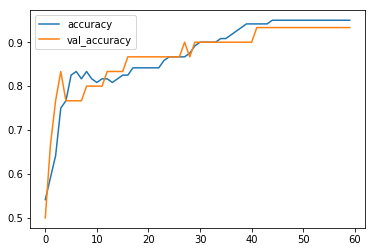

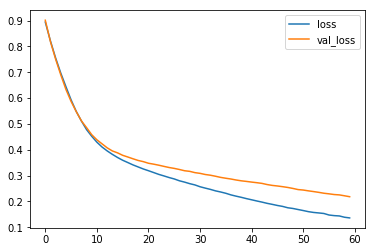

In [10]:
# To show the performance of the ANN during training
# The information has already been saved in "history"

metrics = ann.history
plt.plot(ann.epoch, metrics['accuracy'], metrics['val_accuracy'])
plt.legend(['accuracy', 'val_accuracy'])
plt.show()

plt.plot(ann.epoch, metrics['loss'], metrics['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.show()

In [11]:
print('X_test.shape = ',X_test.shape)
print('Y_test.shape = ',Y_test.shape)
print('X_test[0] = ',X_test[0])
print('Y_test[0] = ',Y_test[0])

# model.predict gives the ANN output with an input
y_ANN_output = model.predict(X_test[0,None])
print('y_ANN_output = ',y_ANN_output)


X_test.shape =  (30, 4)
Y_test.shape =  (30, 3)
X_test[0] =  [-1.50652052  0.78880759 -1.34022653 -1.18381211]
Y_test[0] =  [1. 0. 0.]
y_ANN_output =  [[9.9894720e-01 6.5032736e-04 4.0247550e-04]]


In [12]:
# To check the softmax output from the ANN
check_sum = y_ANN_output[0]
print('check_sum = ',check_sum[0]+check_sum[1]+check_sum[2])

# To get the class label from Y_test
y_ref_result = Y_test[0].argmax().item()
print('y_ref_result = ',y_ref_result)

# To get the class label from ANN
y_ANN_result = y_ANN_output.argmax().item()
print('y_ANN_result = ',y_ANN_result)

check_sum =  1.0
y_ref_result =  0
y_ANN_result =  0


END OF FILE